# DBSCAN + KNN + SMOTE alinhado ao XGBoost temporal

Este notebook adapta o `DBScan_Knn.ipynb` para utilizar a mesma lógica de preparação do `XGBoost_temporal_split(6).ipynb`.

Principais alinhamentos:
- mesma base e mesmo corte temporal (`2018-07-01`);
- mesma definição do alvo: **1 = atraso** e **0 = não atraso**;
- mesmas remoções de colunas;
- mesmas features derivadas;
- mesmo Target Encoding suavizado para `customer_city`, `seller_city` e `category_name`;
- `StandardScaler`;
- validação temporal com `TimeSeriesSplit(n_splits=5)`;
- seleção de limiar usando F1 da classe atraso, com desempate por Recall e Precision;
- balanceamento da classe atraso com SMOTE somente nos dados de treino;
- avaliação com Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score e Log Loss.

> Observação: hiperparâmetros exclusivos do XGBoost (como `max_depth`, `learning_rate`, `gamma` etc.) não existem no KNN. Por isso, a metodologia de busca foi mantida, mas os parâmetros pesquisados são próprios do KNN.


In [1]:
# Célula 1: bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import DBSCAN

try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])
    from imblearn.over_sampling import SMOTE
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay,
)

try:
    import optuna
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


c:\Users\Sofhia\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Célula 2: leitura e preparação — mesma lógica do XGBoost
csv_path = Path("../../tabela_final/table_orders_holidays_ecommerce_events.csv")
df = pd.read_csv(csv_path)

target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' não foi encontrada no CSV.")

# Datas utilizadas pelo XGBoost
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], utc=True)
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"], utc=True)
df["order_delivered_carrier_date"] = pd.to_datetime(df["order_delivered_carrier_date"], utc=True)

# Mesma engenharia de features
df["prazo_transportadora_dias"] = (
    df["order_estimated_delivery_date"] - df["order_delivered_carrier_date"]
).dt.days

df = df.dropna(subset=["prazo_transportadora_dias"]).copy()

df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["prazo_por_km"] = df["prazo_transportadora_dias"] / (df["distance_km"] + 1)
df["frete_por_kg"] = df["freight_value"] / (df["product_weight_g"] / 1000 + 0.1)
df["densidade_produto"] = df["product_weight_g"] / (df["volume_cm3"] + 1)

# Mesma ordenação e split temporal
df = df.sort_values("order_delivered_carrier_date").reset_index(drop=True)
date_col = df["order_delivered_carrier_date"].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()

# MESMA definição do XGBoost:
# delivered_on_time=True  -> 0 (não atraso)
# delivered_on_time=False -> 1 (atraso)
y = (~df[target_col].astype(bool)).astype(int).copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend",
]

X = X.drop(columns=colunas_remover, errors="ignore")

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train_raw = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test_raw = X[test_mask].copy()
y_test = y[test_mask].copy()

print(f"Treino: {len(X_train_raw):,}")
print(f"Teste:  {len(X_test_raw):,}")
print(f"Atrasos no treino: {(y_train == 1).sum():,} ({(y_train == 1).mean():.2%})")
print(f"Atrasos no teste:  {(y_test == 1).sum():,} ({(y_test == 1).mean():.2%})")


Treino: 28,706
Teste:  5,114
Atrasos no treino: 1,425 (4.96%)
Atrasos no teste:  613 (11.99%)


In [3]:
# Célula 3: Target Encoding suavizado — igual ao XGBoost
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

media_global_atraso = y_train.mean()
m = 10

def target_encode_suavizado(train_series, test_series, y_train, media_global, m=10):
    train_series = train_series.fillna("Unknown")
    test_series = test_series.fillna("Unknown")

    counts = train_series.value_counts()
    means = y_train.groupby(train_series).mean()
    smooth = (counts * means + m * media_global) / (counts + m)

    train_encoded = train_series.map(smooth).fillna(media_global)
    test_encoded = test_series.map(smooth).fillna(media_global)
    return train_encoded, test_encoded

X_train["customer_city_encoded"], X_test["customer_city_encoded"] = target_encode_suavizado(
    X_train["customer_city"], X_test["customer_city"], y_train, media_global_atraso, m
)

X_train["seller_city_encoded"], X_test["seller_city_encoded"] = target_encode_suavizado(
    X_train["seller_city"], X_test["seller_city"], y_train, media_global_atraso, m
)

X_train["category_name_encoded"], X_test["category_name_encoded"] = target_encode_suavizado(
    X_train["category_name"], X_test["category_name"], y_train, media_global_atraso, m
)

X_train = X_train.drop(columns=["customer_city", "seller_city", "category_name"])
X_test = X_test.drop(columns=["customer_city", "seller_city", "category_name"])

# Segurança para eventuais nulos numéricos.
medianas_treino = X_train.median(numeric_only=True)
X_train = X_train.fillna(medianas_treino)
X_test = X_test.fillna(medianas_treino)

# Mesma padronização do XGBoost.
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Shape treino:", X_train.shape)
print("Shape teste:", X_test.shape)
print("\nFeatures utilizadas:")
print(X_train.columns.tolist())


Shape treino: (28706, 26)
Shape teste: (5114, 26)

Features utilizadas:
['holiday_at_carrier', 'days_since_last_holiday', 'days_until_next_holiday', 'ecommerce_event_at_carrier', 'days_since_last_ecommerce_event', 'days_until_next_ecommerce_event', 'is_ecommerce_event_in_7_days', 'is_ecommerce_event_in_14_days', 'had_ecommerce_event_7_days_ago', 'had_ecommerce_event_14_days_ago', 'purchase_hour', 'purchase_day_of_week', 'price', 'freight_value', 'product_weight_g', 'volume_cm3', 'distance_km', 'same_city', 'prazo_transportadora_dias', 'purchase_month', 'prazo_por_km', 'frete_por_kg', 'densidade_produto', 'customer_city_encoded', 'seller_city_encoded', 'category_name_encoded']


## DBSCAN

O DBSCAN continua sendo usado como etapa de identificação/remoção de outliers **somente no treino**.  
O conjunto de teste permanece intacto para não alterar artificialmente a avaliação do modelo.


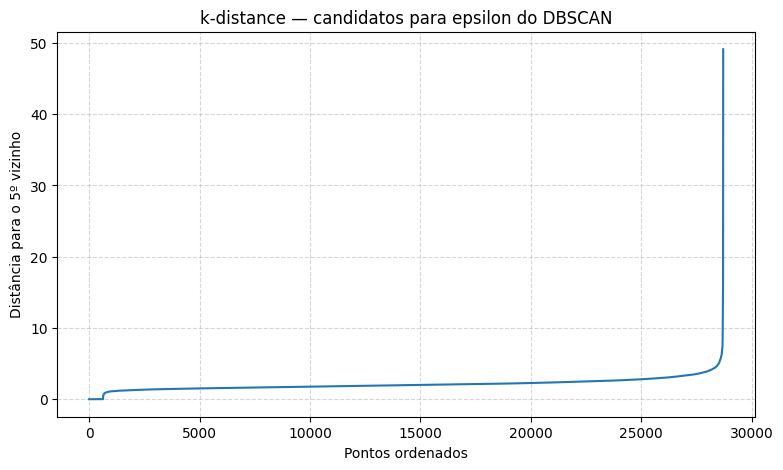

Percentil 90: 2.9716
Percentil 95: 3.4285
Percentil 97: 3.7901
Percentil 99: 4.6305


In [4]:
# Célula 4: k-distance para auxiliar a escolha do epsilon
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_train)
distances, _ = neighbors_fit.kneighbors(X_train)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances, linewidth=1.5)
plt.title("k-distance — candidatos para epsilon do DBSCAN")
plt.xlabel("Pontos ordenados")
plt.ylabel(f"Distância para o {min_samples}º vizinho")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

for p in [90, 95, 97, 99]:
    print(f"Percentil {p}: {np.percentile(k_distances, p):.4f}")


In [5]:
# Célula 5: métricas — mesmas métricas usadas no XGBoost
def metricas_atraso(y_true, y_pred_atraso, y_proba_atraso):
    return {
        "accuracy_atraso": accuracy_score(y_true, y_pred_atraso),
        "precision_atraso": precision_score(y_true, y_pred_atraso, zero_division=0),
        "recall_atraso": recall_score(y_true, y_pred_atraso, zero_division=0),
        "f1_atraso": f1_score(y_true, y_pred_atraso, zero_division=0),
        "f2_atraso": fbeta_score(y_true, y_pred_atraso, beta=2, zero_division=0),
        "roc_auc_atraso": roc_auc_score(y_true, y_proba_atraso),
        "pr_auc_atraso": average_precision_score(y_true, y_proba_atraso),
        "balanced_accuracy_atraso": balanced_accuracy_score(y_true, y_pred_atraso),
        "mcc_atraso": matthews_corrcoef(y_true, y_pred_atraso),
        "brier_score_atraso": brier_score_loss(y_true, y_proba_atraso),
        "log_loss_atraso": log_loss(y_true, y_proba_atraso),
    }

def metricas_gerais(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "F2-score": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
    }

n_trials = 50
study_seed = 42
cv_tune = TimeSeriesSplit(n_splits=5)
threshold_grid_tune = np.arange(0.05, 0.81, 0.01)

print("Configuração de avaliação concluída.")


Configuração de avaliação concluída.


## Balanceamento com SMOTE

Neste notebook, o desbalanceamento da classe alvo é tratado com **SMOTE (Synthetic Minority Over-sampling Technique)**.

A classe positiva continua sendo **1 = atraso**.

Para evitar vazamento de dados:
- o SMOTE **nunca é aplicado ao conjunto de teste**;
- durante o `TimeSeriesSplit`, o SMOTE é aplicado **somente ao fold de treino**;
- o fold de validação permanece com a distribuição real dos dados;
- após a escolha dos melhores hiperparâmetros e do limiar, o SMOTE é aplicado ao conjunto de treino final antes do ajuste definitivo do KNN.

Foi utilizado `SMOTE(random_state=42)`, mantendo a reprodutibilidade do experimento.


In [6]:
# Célula 6: DBSCAN no treino.
# Usamos candidatos baseados nos percentis do k-distance para evitar valores arbitrários.
eps_candidates = sorted(set([
    round(float(np.percentile(k_distances, 90)), 4),
    round(float(np.percentile(k_distances, 95)), 4),
    round(float(np.percentile(k_distances, 97)), 4),
    round(float(np.percentile(k_distances, 99)), 4),
]))

dbscan_resultados = []

for eps in eps_candidates:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels = dbscan.fit_predict(X_train)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    pct_noise = n_noise / len(labels)

    dbscan_resultados.append({
        "eps": eps,
        "clusters": n_clusters,
        "outliers": n_noise,
        "pct_outliers": pct_noise
    })

df_dbscan = pd.DataFrame(dbscan_resultados)
display(df_dbscan)


,eps,clusters,outliers,pct_outliers
0,2.9716,31,1791,0.062391
1,3.4285,13,840,0.029262
2,3.7901,11,503,0.017522
3,4.6305,5,187,0.006514


In [7]:
# Célula 7: escolhe o epsilon sem olhar o conjunto de teste.
# Critério conservador: dentre os candidatos, escolhe o primeiro que remove no máximo 5% do treino.
candidatos_validos = df_dbscan[df_dbscan["pct_outliers"] <= 0.05]

if len(candidatos_validos) > 0:
    best_eps = float(candidatos_validos.iloc[0]["eps"])
else:
    # Se todos removerem mais de 5%, usa o que remove menos registros.
    best_eps = float(df_dbscan.sort_values("pct_outliers").iloc[0]["eps"])

print(f"Epsilon adotado: {best_eps}")

dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples, n_jobs=-1)
dbscan_labels = dbscan_final.fit_predict(X_train)

mask_clean = dbscan_labels != -1
X_train_clean = X_train.loc[mask_clean].copy()
y_train_clean = y_train.loc[mask_clean].copy()

print(f"Treino original: {len(X_train):,}")
print(f"Outliers removidos: {(~mask_clean).sum():,} ({(~mask_clean).mean():.2%})")
print(f"Treino após DBSCAN: {len(X_train_clean):,}")
print(f"Atrasos após DBSCAN: {(y_train_clean == 1).sum():,} ({(y_train_clean == 1).mean():.2%})")


Epsilon adotado: 3.4285
Treino original: 28,706
Outliers removidos: 840 (2.93%)
Treino após DBSCAN: 27,866
Atrasos após DBSCAN: 1,310 (4.70%)


## Otimização do KNN com validação temporal

Como os hiperparâmetros do XGBoost não existem no KNN, o Optuna pesquisa parâmetros equivalentes **do próprio KNN**:
- `n_neighbors`;
- `weights`;
- `p` da distância de Minkowski.

O critério principal continua sendo **PR-AUC**, igual ao XGBoost.  
Para cada configuração, o limiar é escolhido pelo maior F1 da classe atraso, com desempate por Recall e depois Precision.


In [8]:
# Célula 8: Optuna + TimeSeriesSplit + SMOTE para KNN
def objective(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 31, step=2),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2),
    }

    oof_proba = np.full(len(y_train_clean), np.nan, dtype=float)

    # Preserva a ordem temporal do conjunto após a remoção dos outliers.
    X_cv = X_train_clean.reset_index(drop=True)
    y_cv = y_train_clean.reset_index(drop=True)

    for tr_idx, va_idx in cv_tune.split(X_cv):
        X_tr, X_va = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
        y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

        # IMPORTANTE:
        # SMOTE é aplicado APENAS no fold de treino.
        # A validação mantém a distribuição original.
        smote_fold = SMOTE(random_state=42)
        X_tr_smote, y_tr_smote = smote_fold.fit_resample(X_tr, y_tr)

        mdl = KNeighborsClassifier(
            n_jobs=-1,
            **params
        )
        mdl.fit(X_tr_smote, y_tr_smote)
        oof_proba[va_idx] = mdl.predict_proba(X_va)[:, 1]

    valid = ~np.isnan(oof_proba)
    y_valid = y_cv.iloc[np.where(valid)[0]]
    proba_valid = oof_proba[valid]

    pr_auc_i = average_precision_score(y_valid, proba_valid)

    best_thr_i = 0.50
    best_f1_i = -1.0
    best_recall_i = -1.0
    best_precision_i = -1.0

    for thr in threshold_grid_tune:
        pred = (proba_valid >= thr).astype(int)
        precision_i = precision_score(y_valid, pred, zero_division=0)
        recall_i = recall_score(y_valid, pred, zero_division=0)
        f1_i = f1_score(y_valid, pred, zero_division=0)

        if (
            (f1_i > best_f1_i)
            or (np.isclose(f1_i, best_f1_i) and recall_i > best_recall_i)
            or (
                np.isclose(f1_i, best_f1_i)
                and np.isclose(recall_i, best_recall_i)
                and precision_i > best_precision_i
            )
        ):
            best_f1_i = float(f1_i)
            best_recall_i = float(recall_i)
            best_precision_i = float(precision_i)
            best_thr_i = float(thr)

    trial.set_user_attr("best_threshold", best_thr_i)
    trial.set_user_attr("cv_pr_auc_atraso", float(pr_auc_i))
    trial.set_user_attr("cv_f1_atraso", best_f1_i)
    trial.set_user_attr("cv_recall_atraso", best_recall_i)
    trial.set_user_attr("cv_precision_atraso", best_precision_i)

    return pr_auc_i

sampler = optuna.samplers.TPESampler(seed=study_seed)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

best_trial = study.best_trial
best_params_knn = best_trial.params
best_threshold_knn = float(best_trial.user_attrs["best_threshold"])

print("Melhores parâmetros do KNN:")
for k, v in best_params_knn.items():
    print(f" - {k}: {v}")

print(f"Melhor limiar: {best_threshold_knn:.2f}")
print(f"PR-AUC CV: {best_trial.user_attrs['cv_pr_auc_atraso']:.4f}")
print(f"F1 atraso CV: {best_trial.user_attrs['cv_f1_atraso']:.4f}")
print(f"Recall atraso CV: {best_trial.user_attrs['cv_recall_atraso']:.4f}")
print(f"Precision atraso CV: {best_trial.user_attrs['cv_precision_atraso']:.4f}")


[I 2026-10-04 13:50:36,352] A new study created in memory with name: no-name-1c338ee2-a69f-4f51-88d1-5384d888d592
[I 2026-10-04 13:50:39,578] Trial 0 finished with value: 0.07543083100108035 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.07543083100108035.
[I 2026-10-04 13:50:42,208] Trial 1 finished with value: 0.07092939136258056 and parameters: {'n_neighbors': 7, 'weights': 'uniform', 'p': 2}. Best is trial 0 with value: 0.07543083100108035.
[I 2026-10-04 13:50:44,782] Trial 2 finished with value: 0.07758627488398798 and parameters: {'n_neighbors': 21, 'weights': 'uniform', 'p': 2}. Best is trial 2 with value: 0.07758627488398798.
[I 2026-10-04 13:50:51,201] Trial 3 finished with value: 0.07922638092452751 and parameters: {'n_neighbors': 27, 'weights': 'uniform', 'p': 1}. Best is trial 3 with value: 0.07922638092452751.
[I 2026-10-04 13:50:57,412] Trial 4 finished with value: 0.07181751027842885 and parameters: {'n_neighbors': 11, 'w

Melhores parâmetros do KNN:
 - n_neighbors: 27
 - weights: distance
 - p: 1
Melhor limiar: 0.63
PR-AUC CV: 0.0806
F1 atraso CV: 0.1343
Recall atraso CV: 0.3810
Precision atraso CV: 0.0815


In [9]:
# Célula 9: SMOTE no conjunto de treino final
print("Distribuição ANTES do SMOTE:")
print(y_train_clean.value_counts().sort_index())
print(y_train_clean.value_counts(normalize=True).sort_index().round(4))

smote_final = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote_final.fit_resample(
    X_train_clean,
    y_train_clean
)

print("\nDistribuição DEPOIS do SMOTE:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(pd.Series(y_train_smote).value_counts(normalize=True).sort_index().round(4))

print(f"\nTreino antes do SMOTE: {len(X_train_clean):,}")
print(f"Treino depois do SMOTE: {len(X_train_smote):,}")
print("O conjunto de teste NÃO foi alterado.")


Distribuição ANTES do SMOTE:
delivered_on_time
0    26556
1     1310
Name: count, dtype: int64
delivered_on_time
0    0.953
1    0.047
Name: proportion, dtype: float64

Distribuição DEPOIS do SMOTE:
delivered_on_time
0    26556
1    26556
Name: count, dtype: int64
delivered_on_time
0    0.5
1    0.5
Name: proportion, dtype: float64

Treino antes do SMOTE: 27,866
Treino depois do SMOTE: 53,112
O conjunto de teste NÃO foi alterado.


Métricas no TESTE — foco na classe atraso:


,Teste
accuracy_atraso,0.7961
precision_atraso,0.2506
recall_atraso,0.3524
f1_atraso,0.2929
f2_atraso,0.3259
roc_auc_atraso,0.7015
pr_auc_atraso,0.2277
balanced_accuracy_atraso,0.6044
mcc_atraso,0.1812
brier_score_atraso,0.1779


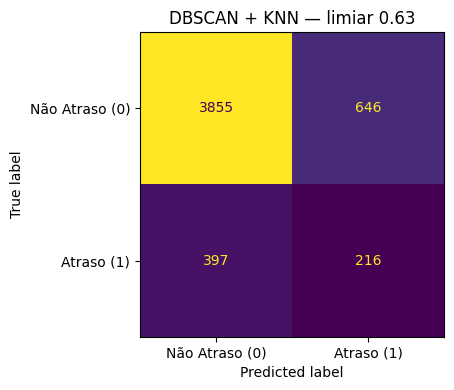

In [10]:
# Célula 10: treino final do KNN com SMOTE e avaliação no teste
model_knn = KNeighborsClassifier(
    n_jobs=-1,
    **best_params_knn
)

model_knn.fit(X_train_smote, y_train_smote)

y_proba_train = model_knn.predict_proba(X_train_clean)[:, 1]
y_proba_test = model_knn.predict_proba(X_test)[:, 1]

y_pred_train = (y_proba_train >= best_threshold_knn).astype(int)
y_pred_test = (y_proba_test >= best_threshold_knn).astype(int)

res_train = metricas_atraso(y_train_clean, y_pred_train, y_proba_train)
res_test = metricas_atraso(y_test, y_pred_test, y_proba_test)

metricas_treino = metricas_gerais(y_train_clean, y_pred_train, y_proba_train)
metricas_teste = metricas_gerais(y_test, y_pred_test, y_proba_test)

print("Métricas no TESTE — foco na classe atraso:")
display(pd.DataFrame(pd.Series(res_test, name="Teste")).round(4))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    ax=ax,
    colorbar=False,
    display_labels=["Não Atraso (0)", "Atraso (1)"]
)
ax.set_title(f"DBSCAN + KNN — limiar {best_threshold_knn:.2f}")
plt.tight_layout()
plt.show()


In [11]:
# Célula 11: tabela final de métricas, no mesmo formato conceitual do XGBoost
print("=" * 110)
print("MÉTRICAS — DBSCAN + KNN")
print("=" * 110)

df_metricas = pd.DataFrame({
    "Treino": metricas_treino,
    "Teste": metricas_teste
}).T

display(df_metricas.round(4))

print("\nResumo do TESTE:")
print(f"- Accuracy: {metricas_teste['Accuracy']:.4f}")
print(f"- Precision atraso: {res_test['precision_atraso']:.4f}")
print(f"- Recall atraso: {res_test['recall_atraso']:.4f}")
print(f"- F1 atraso: {res_test['f1_atraso']:.4f}")
print(f"- F2 atraso: {res_test['f2_atraso']:.4f}")
print(f"- ROC-AUC: {res_test['roc_auc_atraso']:.4f}")
print(f"- PR-AUC: {res_test['pr_auc_atraso']:.4f}")
print(f"- Balanced Accuracy: {res_test['balanced_accuracy_atraso']:.4f}")
print(f"- MCC: {res_test['mcc_atraso']:.4f}")


MÉTRICAS — DBSCAN + KNN


,Accuracy,Precision,Recall,F1-score,F2-score,ROC-AUC,PR-AUC,Balanced Accuracy,MCC,Brier Score,Log Loss
Treino,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000
Teste,0.7961,0.2506,0.3524,0.2929,0.3259,0.7015,0.2277,0.6044,0.1812,0.1779,0.8503



Resumo do TESTE:
- Accuracy: 0.7961
- Precision atraso: 0.2506
- Recall atraso: 0.3524
- F1 atraso: 0.2929
- F2 atraso: 0.3259
- ROC-AUC: 0.7015
- PR-AUC: 0.2277
- Balanced Accuracy: 0.6044
- MCC: 0.1812


## O que foi alterado em relação ao DBScan_Knn original

1. O split temporal passou a seguir exatamente a referência do XGBoost.
2. A classe positiva passou a ser **atraso = 1**, permitindo comparar Precision, Recall, F1 e F2 diretamente.
3. Foram adicionadas as mesmas features derivadas do XGBoost.
4. Foram aplicadas as mesmas remoções de colunas.
5. `customer_city`, `seller_city` e `category_name` passaram pelo mesmo Target Encoding suavizado.
6. A padronização continua sendo usada, o que é especialmente importante para KNN e DBSCAN.
7. O DBSCAN remove outliers apenas do treino; o teste não é alterado.
8. O KNN passou a usar `TimeSeriesSplit` e Optuna.
9. A otimização principal passou de F1 ponderado para **PR-AUC**, como no XGBoost.
10. O limiar de classificação passou a ser otimizado em vez de ficar fixo em 0,5.
11. Foram adicionadas as mesmas métricas de comparação usadas no XGBoost.
12. Foi adicionado SMOTE somente no treino, inclusive dentro de cada fold temporal do Optuna, evitando vazamento para validação e teste.
